In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [39]:

df_clean = pd.read_csv('../data/cleaned_retail.csv')


In [40]:
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

df_clean['FirstInvoiceDate'] = df_clean.groupby('CustomerID')['InvoiceDate'].transform('min')
df_clean['CohortMonth'] = df_clean['FirstInvoiceDate'].dt.to_period('M')
df_clean['InvoiceMonth'] = df_clean['InvoiceDate'].dt.to_period('M')
df_clean['CohortIndex'] = (df_clean['InvoiceMonth'] - df_clean['CohortMonth']).apply(lambda x: x.n)

display(df_clean[['CustomerID', 'InvoiceDate', 'CohortMonth', 'InvoiceMonth', 'CohortIndex']].head())





,CustomerID,InvoiceDate,CohortMonth,InvoiceMonth,CohortIndex
0,17850,2010-12-01 08:26:00,2010-12,2010-12,0
1,17850,2010-12-01 08:26:00,2010-12,2010-12,0
2,17850,2010-12-01 08:26:00,2010-12,2010-12,0
3,17850,2010-12-01 08:26:00,2010-12,2010-12,0
4,17850,2010-12-01 08:26:00,2010-12,2010-12,0


In [41]:
cohort_data = df_clean.groupby(['CohortMonth', 'CohortIndex'])['CustomerID'].nunique().reset_index()

In [42]:
cohort_pivot = cohort_data.pivot_table(index='CohortMonth', columns='CohortIndex', values='CustomerID')
display(cohort_pivot)

CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11,12
CohortMonth,,,,,,,,,,,,,
2010-12,885.0,324.0,286.0,340.0,321.0,352.0,321.0,309.0,313.0,350.0,331.0,445.0,235.0
2011-01,416.0,92.0,111.0,96.0,134.0,120.0,103.0,101.0,125.0,136.0,152.0,49.0,NaN
2011-02,380.0,71.0,71.0,108.0,103.0,94.0,96.0,106.0,94.0,116.0,26.0,NaN,NaN
2011-03,452.0,67.0,114.0,90.0,101.0,76.0,121.0,104.0,126.0,39.0,NaN,NaN,NaN
2011-04,300.0,64.0,61.0,63.0,59.0,68.0,65.0,78.0,22.0,NaN,NaN,NaN,NaN
2011-05,284.0,54.0,49.0,49.0,59.0,66.0,75.0,26.0,NaN,NaN,NaN,NaN,NaN
2011-06,242.0,42.0,38.0,64.0,56.0,81.0,23.0,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,188.0,34.0,39.0,42.0,51.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,169.0,35.0,42.0,41.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [43]:
cohort_size = cohort_pivot.iloc[:, 0]
retention = cohort_pivot.divide(cohort_size, axis=0)

In [44]:
display((retention * 100).round(1))

CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11,12
CohortMonth,,,,,,,,,,,,,
2010-12,100.0,36.6,32.3,38.4,36.3,39.8,36.3,34.9,35.4,39.5,37.4,50.3,26.6
2011-01,100.0,22.1,26.7,23.1,32.2,28.8,24.8,24.3,30.0,32.7,36.5,11.8,NaN
2011-02,100.0,18.7,18.7,28.4,27.1,24.7,25.3,27.9,24.7,30.5,6.8,NaN,NaN
2011-03,100.0,14.8,25.2,19.9,22.3,16.8,26.8,23.0,27.9,8.6,NaN,NaN,NaN
2011-04,100.0,21.3,20.3,21.0,19.7,22.7,21.7,26.0,7.3,NaN,NaN,NaN,NaN
2011-05,100.0,19.0,17.3,17.3,20.8,23.2,26.4,9.2,NaN,NaN,NaN,NaN,NaN
2011-06,100.0,17.4,15.7,26.4,23.1,33.5,9.5,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,100.0,18.1,20.7,22.3,27.1,11.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,100.0,20.7,24.9,24.3,12.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [46]:
df_clean.to_csv('../data/clean_cohorts.csv', index=False)

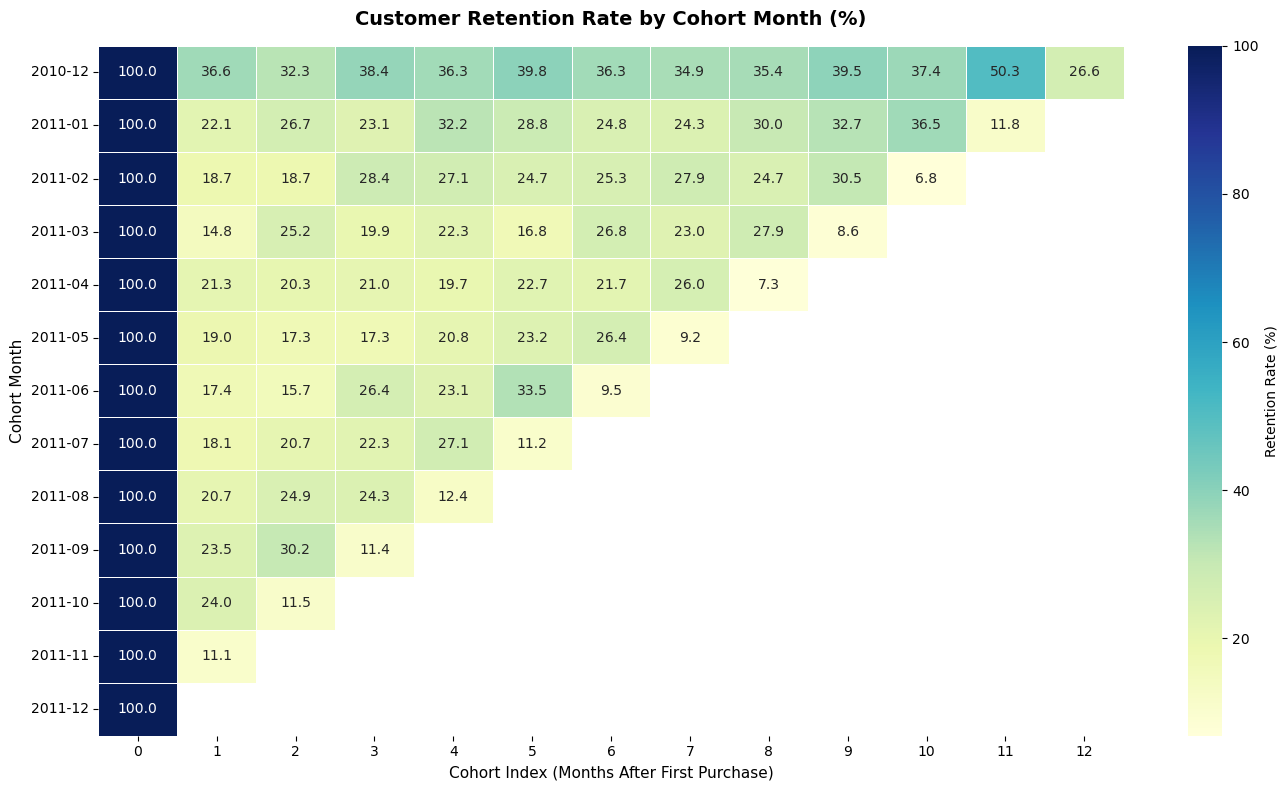

In [ ]:
plt.figure(figsize=(14, 8))

sns.heatmap(
    retention * 100, 
    annot=True, 
    fmt='.1f', 
    cmap='YlGnBu', 
    linewidths=0.5,
    cbar_kws={'label': 'Retention Rate (%)'}
)

plt.title('Customer Retention Rate by Cohort Month (%)', fontsize=14, pad=15, weight='bold')
plt.xlabel('Cohort Index (Months After First Purchase)', fontsize=11)
plt.ylabel('Cohort Month', fontsize=11)

plt.tight_layout()
plt.show()


### Cohort & Retention Analysis Insights
The longitudinal cohort analysis reveals an exceptional benchmark core in the initial December 2010 cohort (885 buyers, maintaining an average ~36% monthly retention rate and peaking at 50.3% in Month 11). However, across all 2011 cohorts, the business faces a critical Month 1 retention bottleneck, retaining only 11.1% to 24.0% of new users—representing an immediate 76–89% churn rate within the first 30 days post-purchase. Furthermore, a synchronized retention surge across all active cohorts every November underscores a powerful Q4 holiday seasonality. Strategic priority must focus on deploying automated onboarding workflows within the first 30 days to mitigate early drop-off and leveraging Q4 seasonal campaigns to trigger repeat purchases among dormant cohorts.